**Importy**

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scripts.unpack_root_dataset import main_unpack
from scripts.create_splits import create_splits
from scripts.scaler import rescale_all_images
from scripts.wczytaj_obrazy import load_images
from scripts.svm import SVMClassifier
from scripts.metrics import calculate_metrics, plot_confusion_matrix
from scripts.hog_color_spatial import policz_hog_kolor_spatial_batch
from scripts.pca_utils import (dopasuj_pca_nkomp, przeksztalc_pca)
from scripts.BOVW_sift import (zbuduj_slownik_sift_bovw, policz_bovw_dla_obrazow)
from scripts.texture_matcher import TextureMatcher

### Tworzenie naszego datasetu

In [2]:
FORCE_REEXTRACT = False #jeśli True robi wszystko od nowa, jeśli False to sprawdza czy pliki istnieją i reszte pomija

main_unpack(force_extract=FORCE_REEXTRACT)
create_splits(force_extract=FORCE_REEXTRACT)

#przeskalowanie + paddding
rescale_all_images(force_extract=FORCE_REEXTRACT)

Dataset już istnieje i nie jest pusty wiec pomijam rozpakowywanie
Pliki CSV już istnieją i mają zawartość. Pomijam.
Przeskalowany dataset już istnieje i nie jest pusty. Pomijam rozpakowywanie.


Wczytanie obrazów

In [3]:
train_images, train_paths = load_images("train", scaled=True)
test_images, test_paths = load_images("test", scaled=True)

print("Liczba obrazów w train:", len(train_images))
print("Kształt pierwszego obrazu:", train_images[0].shape)
print("Liczba obrazów w test:", len(test_images))
print("Kształt pierwszego obrazu w teście:", test_images[0].shape)

Liczba obrazów w train: 6107
Kształt pierwszego obrazu: (256, 256, 3)
Liczba obrazów w test: 1527
Kształt pierwszego obrazu w teście: (256, 256, 3)


Sprawdzenie ile w każdej klasie mamy obrazów

In [4]:
train = pd.read_csv("dataset/train.csv")
print("\nTRAIN:")
print(train["class"].value_counts())
print("SUMA:", len(train))

test = pd.read_csv("dataset/test.csv")
print("\nTEST:")
print(test["class"].value_counts())
print("SUMA:", len(test))



TRAIN:
class
rhino       1102
zebra       1065
elephant    1032
lion        1009
giraffe      991
cheetah      908
Name: count, dtype: int64
SUMA: 6107

TEST:
class
rhino       287
lion        268
zebra       256
elephant    256
cheetah     242
giraffe     218
Name: count, dtype: int64
SUMA: 1527


## Stabilne 70 % skuteczności

https://www.sciencedirect.com/science/article/pii/S1574954124000839

Liczba obrazów train: 6107
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']

Etap nr 1 --> HOG + KOLOR + SPATIAL
Robimy PCA na HOGu

Etap nr 2 --> BoVW (SIFT)
Zbieram deskryptory SIFT do budowy słownika
Łączna liczba deskryptorów do KMeans --> 850762
trening MiniBatchKMeans (słownik BoVW) -->
Init 1/1 with method k-means++
Inertia for init 1/1: 311793920.0
[MiniBatchKMeans] Reassigning 293 cluster centers.
Minibatch step 1/85076: mean batch inertia: 104674.304
Minibatch step 2/85076: mean batch inertia: 93266.648, ewa inertia: 93266.648
Minibatch step 3/85076: mean batch inertia: 89362.344, ewa inertia: 93257.46964127965
Minibatch step 4/85076: mean batch inertia: 84985.4, ewa inertia: 93238.02340386387
Minibatch step 5/85076: mean batch inertia: 83117.584, ewa inertia: 93214.23196158474
Minibatch step 6/85076: mean batch inertia: 81670.368, ewa inertia: 93187.09428878612
Minibatch step 7/85076: mean batch inertia: 80766.36, ewa inertia: 93157.89524207443
Minibatch s

<Figure size 600x600 with 0 Axes>

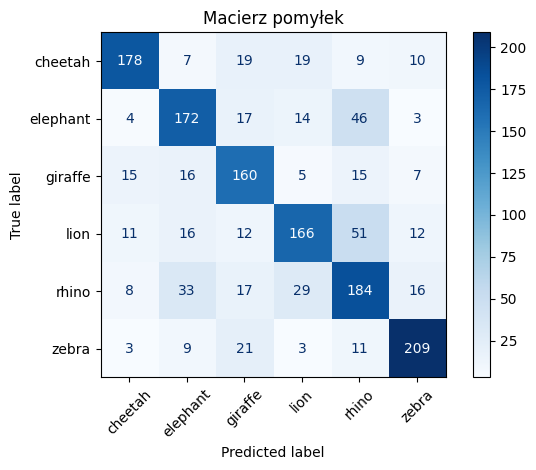

In [5]:
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print(f"Liczba obrazów train: {len(train_images)}")
print(f"Klasy: {class_names}")

#HOG + KOLOR + SPATIAL
print("\nEtap nr 1 --> HOG + KOLOR + SPATIAL")
X_train_hog = policz_hog_kolor_spatial_batch(train_images)
X_test_hog = policz_hog_kolor_spatial_batch(test_images)

print("Robimy PCA na HOGu")
pca_hog, X_train_hog_pca = dopasuj_pca_nkomp(X_train_hog, n_components=384)
X_test_hog_pca = przeksztalc_pca(pca_hog, X_test_hog)

scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog_pca)
X_test_hog_scaled = scaler_hog.transform(X_test_hog_pca)

#BoVW (SIFT)
print("\nEtap nr 2 --> BoVW (SIFT)")
sift, kmeans = zbuduj_slownik_sift_bovw(train_images, n_clusters=768, max_images=2500, max_kp_per_image=400, random_state=42)
X_train_bovw = policz_bovw_dla_obrazow(train_images, sift, kmeans, max_kp_per_image=600)
X_test_bovw = policz_bovw_dla_obrazow(test_images, sift, kmeans, max_kp_per_image=600)

#Normalizacja
X_train_bovw = np.sqrt(np.clip(X_train_bovw, 0, None))
X_test_bovw  = np.sqrt(np.clip(X_test_bovw, 0, None))
X_train_bovw = X_train_bovw / (np.linalg.norm(X_train_bovw, axis=1, keepdims=True) + 1e-12)
X_test_bovw  = X_test_bovw  / (np.linalg.norm(X_test_bovw,  axis=1, keepdims=True) + 1e-12)

scaler_bovw = StandardScaler(with_mean=False)
X_train_bovw_scaled = scaler_bovw.fit_transform(X_train_bovw)
X_test_bovw_scaled  = scaler_bovw.transform(X_test_bovw)

#PCA na BoVW - Wracamy do stabilnego 180
print("PCA na BoVW")
pca_bovw = PCA(n_components=180)
X_train_bovw_pca = pca_bovw.fit_transform(X_train_bovw_scaled)
X_test_bovw_pca = pca_bovw.transform(X_test_bovw_scaled)

#TEKSTURY (Multi-Scale + CLAHE)
print("\nEtap nr 3 --> Texture matching")
tex_matcher = TextureMatcher(textures_dir="dataset/textures", class_names=class_names, base_size=80)

X_train_tex = tex_matcher.compute_features(train_images)
X_test_tex = tex_matcher.compute_features(test_images)

scaler_tex = StandardScaler()
X_train_tex_scaled = scaler_tex.fit_transform(X_train_tex)
X_test_tex_scaled = scaler_tex.transform(X_test_tex)

#DELIKATNE WAŻENIE --> Nie x3.0, bo to było za dużo. 
#x1.5 da znać SVM-owi, że te cechy są ważne, ale nie zdominuje HOG-a.
WEIGHT = 1.5
X_train_tex_scaled = X_train_tex_scaled * WEIGHT
X_test_tex_scaled = X_test_tex_scaled * WEIGHT

#Łaczenie (COMBO)
print("\nEtap 4 --> łączenie wszystkich cech (COMBO)")
# HOG(384) + BoVW(180) + TEX(6) = 570 cech
X_train_combo = np.hstack([X_train_hog_scaled, X_train_bovw_pca, X_train_tex_scaled])
X_test_combo = np.hstack([X_test_hog_scaled, X_test_bovw_pca, X_test_tex_scaled])

print("Finalny kształt macierzy train:", X_train_combo.shape)
print("Finalny kształt macierzy test:", X_test_combo.shape)

#Trening SVM
print("\nEtap 5 --> Trening SVM...")
svm = SVMClassifier(C=2.0, kernel="rbf", gamma="scale")
svm.fit(X_train_combo, y_train)

#predykcja
print("\nEtap 6 --> Predykcja na zbiorze testowym")
y_pred = svm.predict(X_test_combo)

accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("\nWyniki Końcowe:")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test, y_pred, labels=class_names)